<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/python-ex/blob/main/Ecommerce_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Inspecting the Dataset

In [ ]:
import pandas as pd
pd.read_excel('Ecommerce_Sales_Dataset.xlsx')

,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,ORD100000,2023-12-25,CUST10535,West,Fashion,Formal Shirt,1,1375.76,1375.76,Debit Card
1,ORD100001,2023-06-06,CUST14643,West,Fashion,Denim Jeans,1,1811.95,1630.76,Credit Card
2,ORD100002,2024-02-05,CUST13927,North,Fashion,Winter Jacket,1,3431.87,3431.87,UPI
3,ORD100003,2024-02-09,CUST12633,South,Electronics,Bluetooth Speaker,3,783.88,2234.06,Credit Card
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery
...,...,...,...,...,...,...,...,...,...,...
19995,ORD113303,2024-07-03,CUST15935,North,Fashion,Leather Wallet,1,2535.57,2535.57,Credit Card
19996,ORD117988,2024-08-13,CUST10241,North,Sports,Cricket Bat,1,468.96,422.06,Debit Card
19997,ORD118709,2024-07-04,CUST14116,North,Grocery,Organic Rice 5kg,1,970.23,776.18,Cash on Delivery
19998,ORD104464,2023-11-18,CUST12674,North,Beauty,Sunscreen SPF50,1,1151.94,1151.94,UPI


In [ ]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19975 entries, 0 to 19974
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        19975 non-null  object        
 1   OrderDate      19975 non-null  datetime64[ns]
 2   CustomerID     19975 non-null  object        
 3   Region         19975 non-null  object        
 4   Category       19975 non-null  object        
 5   Product        19975 non-null  object        
 6   Quantity       19975 non-null  int64         
 7   UnitPrice      19975 non-null  float64       
 8   TotalAmount    19975 non-null  float64       
 9   PaymentMethod  19975 non-null  object        
 10  OrderMonth     19975 non-null  period[M]     
 11  price_band     19975 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(6), period[M](1)
memory usage: 1.8+ MB


In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,OrderDate,Quantity,UnitPrice,TotalAmount
count,19975,19975.000000,19975.000000,19975.000000
mean,2024-01-01 11:52:58.272840960,1.475444,1625.997542,2276.359551
min,2023-01-01 00:00:00,1.000000,49.650000,39.190000
25%,2023-07-02 00:00:00,1.000000,635.245000,723.465000
50%,2024-01-02 00:00:00,1.000000,1261.960000,1565.780000
75%,2024-07-03 00:00:00,2.000000,2498.970000,2939.340000
max,2024-12-31 00:00:00,5.000000,4998.600000,24484.750000
std,NaN,0.879825,1209.104407,2407.242796


In [ ]:
# Display the number of unique values for each column
display(df.nunique())

,0
OrderID,19975
OrderDate,731
CustomerID,5772
Region,4
Category,7
Product,56
Quantity,5
UnitPrice,19387
TotalAmount,19484
PaymentMethod,6


## Handling Missing Values

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


As observed, 'Region' and 'PaymentMethod' have missing values. Since these are categorical columns, I'll impute them with their respective modes.

In [ ]:
# Impute 'Region' and 'PaymentMethod' with their modes
df['Region'].fillna(df['Region'].mode()[0], inplace=True)
df['PaymentMethod'].fillna(df['PaymentMethod'].mode()[0], inplace=True)

# Verify that there are no more missing values
missing_values_after_imputation = df.isnull().sum()
display(missing_values_after_imputation[missing_values_after_imputation > 0])

print("Missing values after imputation:")
print(missing_values_after_imputation[missing_values_after_imputation > 0])

/tmp/ipykernel_955/3456962220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Region'].fillna(df['Region'].mode()[0], inplace=True)
/tmp/ipykernel_955/3456962220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0


Missing values after imputation:
Series([], dtype: int64)


## Data Type Conversion

In [ ]:
# Convert 'OrderDate' to datetime objects
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Display the DataFrame info after conversion to verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19975 entries, 0 to 19974
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        19975 non-null  object        
 1   OrderDate      19975 non-null  datetime64[ns]
 2   CustomerID     19975 non-null  object        
 3   Region         19975 non-null  object        
 4   Category       19975 non-null  object        
 5   Product        19975 non-null  object        
 6   Quantity       19975 non-null  int64         
 7   UnitPrice      19975 non-null  float64       
 8   TotalAmount    19975 non-null  float64       
 9   PaymentMethod  19975 non-null  object        
 10  OrderMonth     19975 non-null  period[M]     
 11  price_band     19975 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(6), period[M](1)
memory usage: 1.8+ MB


## Removing Duplicate Records

In [ ]:
# Check for duplicate rows
initial_rows = df.shape[0]
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

# Remove duplicate rows if any exist
if num_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New number of rows: {df.shape[0]}")
else:
    print("No duplicate rows found.")

# Display the shape of the DataFrame after removing duplicates
print(f"DataFrame shape after duplicate removal: {df.shape}")

Number of duplicate rows found: 0
No duplicate rows found.
DataFrame shape after duplicate removal: (19975, 12)


## Revenue by Category

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue by category
revenue_by_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Display the results
display(revenue_by_category)

,Category,TotalAmount
0,Electronics,16637101.98
1,Fashion,10291758.80
2,Home & Kitchen,6409462.66
3,Sports,6242873.76
4,Beauty,2962151.51
5,Grocery,1486088.16
6,Books,1440845.17


/tmp/ipykernel_955/371448772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='TotalAmount', data=revenue_by_category, palette='viridis')


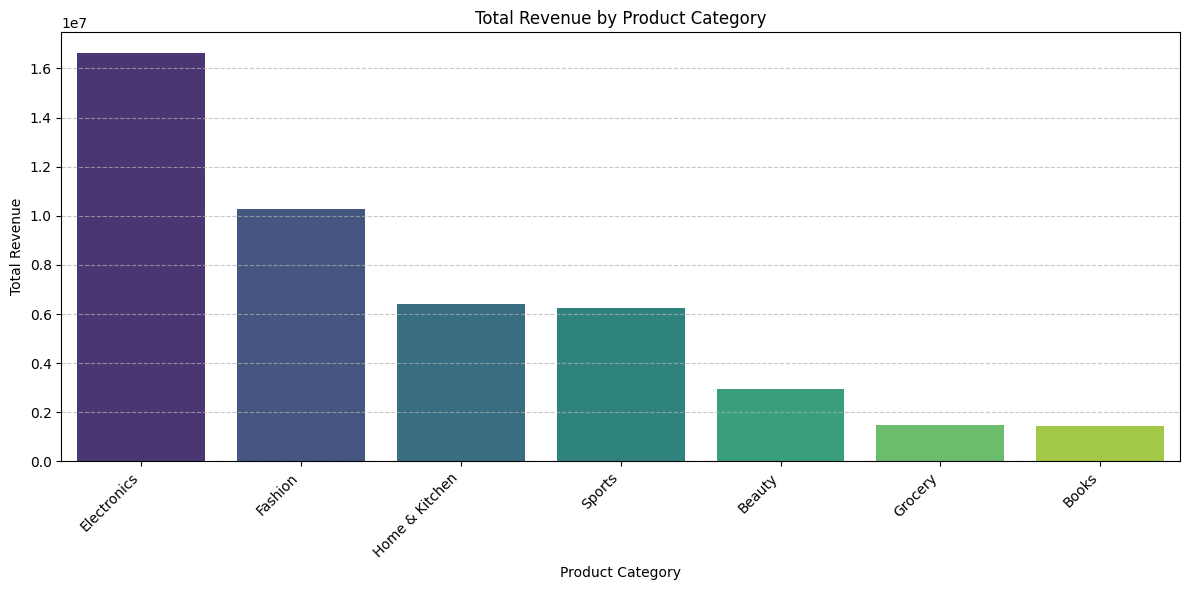

In [ ]:
# Visualize revenue by category
fig = plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='TotalAmount', data=revenue_by_category, palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Regional Performance Summary

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue by region
revenue_by_region = df.groupby('Region')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Display the results
display(revenue_by_region)

,Region,TotalAmount
0,South,11650112.94
1,North,11498741.63
2,East,11220270.41
3,West,11101157.06


/tmp/ipykernel_955/1372491044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='TotalAmount', data=revenue_by_region, palette='magma')


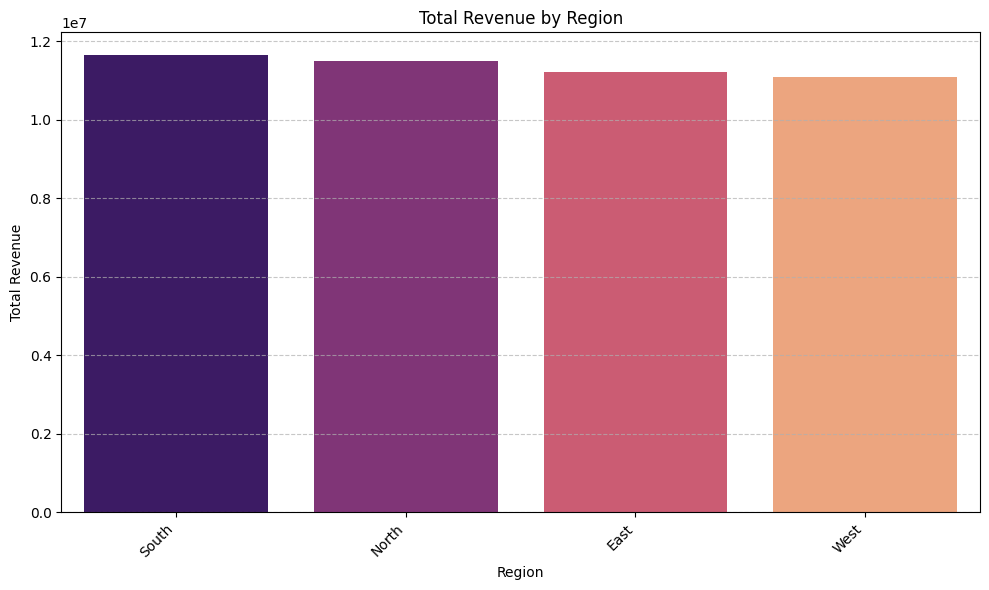

In [ ]:
# Visualize revenue by region
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='TotalAmount', data=revenue_by_region, palette='magma')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Most Popular Products by Revenue

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue by product
revenue_by_product = df.groupby('Product')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Display the top 10 products by revenue
display(revenue_by_product.head(10))

,Product,TotalAmount
0,Wireless Earbuds,2235080.46
1,Laptop Stand,2134893.25
2,Smartphone Case,2076527.35
3,Bluetooth Speaker,2070685.40
4,USB-C Cable,2038301.29
5,Smartwatch,2037562.31
6,Power Bank,2030612.43
7,Webcam,2013439.49
8,Sunglasses,1455940.53
9,Leather Wallet,1357791.62


/tmp/ipykernel_955/1611429532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalAmount', y='Product', data=revenue_by_product.head(10), palette='crest')


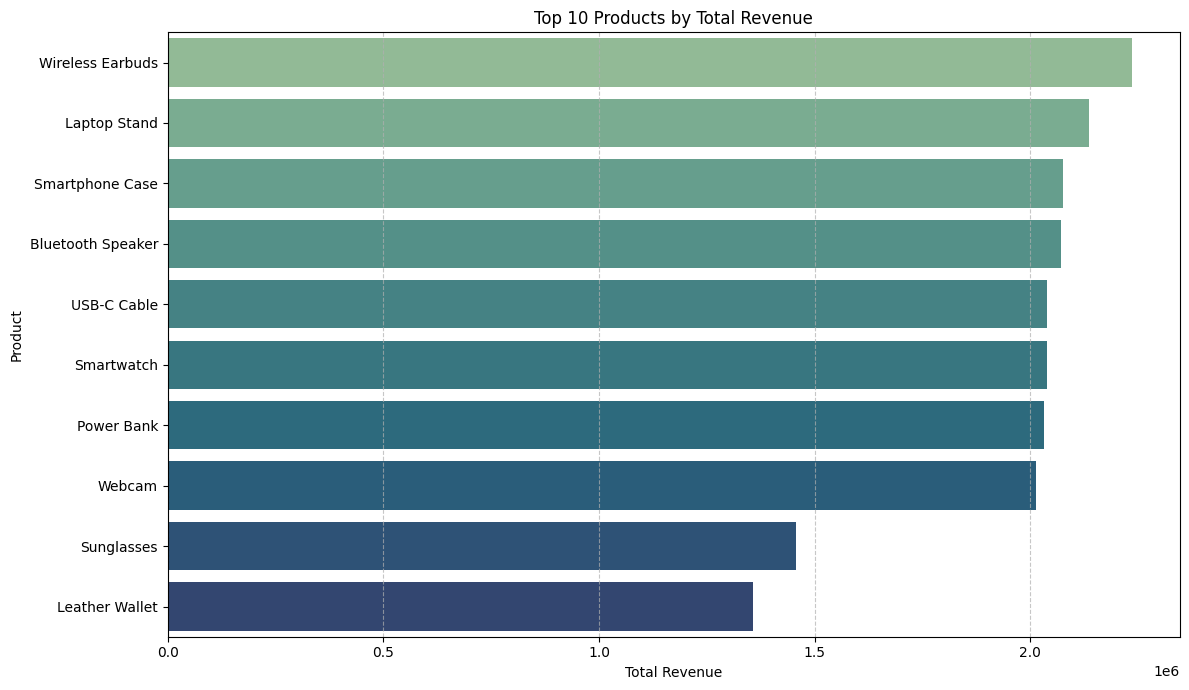

In [ ]:
# Visualize the top 10 products by revenue
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='TotalAmount', y='Product', data=revenue_by_product.head(10), palette='crest')
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Monthly Sales Trend

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month from OrderDate
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')

# Calculate total sales by month
monthly_sales = df.groupby('OrderMonth')['TotalAmount'].sum().reset_index()

# Convert OrderMonth back to datetime for proper plotting
monthly_sales['OrderMonth'] = monthly_sales['OrderMonth'].dt.to_timestamp()

# Display the monthly sales data
display(monthly_sales)

,OrderMonth,TotalAmount
0,2023-01-01,1811221.85
1,2023-02-01,1780493.19
2,2023-03-01,1874014.66
3,2023-04-01,2026960.14
4,2023-05-01,1911494.17
5,2023-06-01,1878274.25
6,2023-07-01,1905700.67
7,2023-08-01,1870680.13
8,2023-09-01,1814877.66
9,2023-10-01,1915180.30


/tmp/ipykernel_955/1838048642.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='OrderMonth', y='TotalAmount', data=monthly_sales, marker='o', palette='viridis')


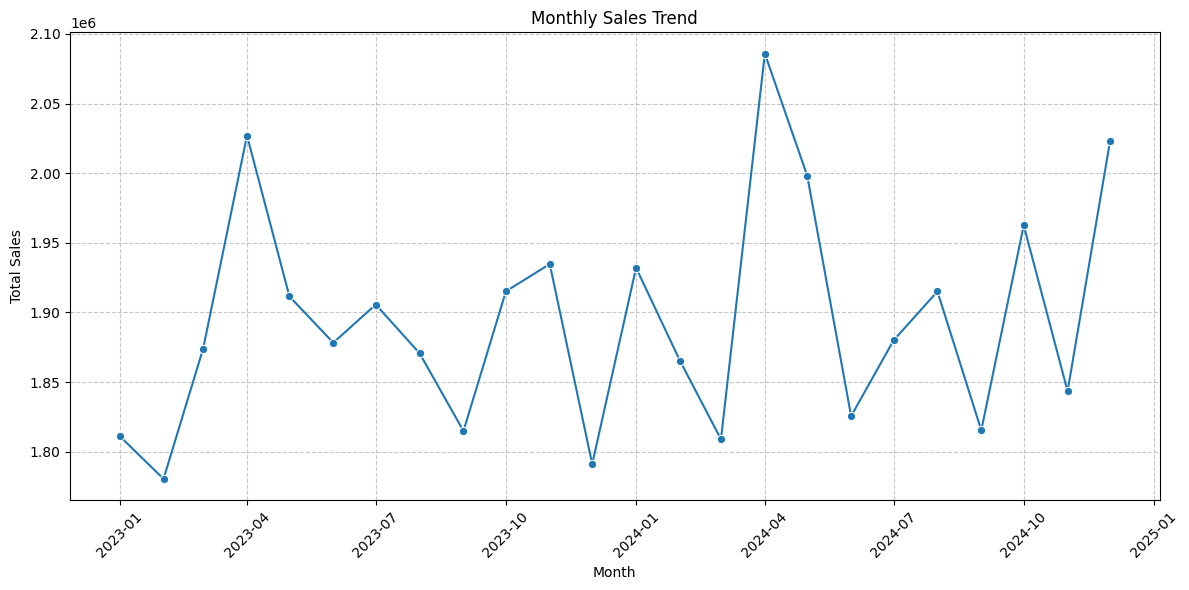

In [ ]:
# Visualize monthly sales trend
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x='OrderMonth', y='TotalAmount', data=monthly_sales, marker='o', palette='viridis')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Payment Method Preferences

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count of each payment method
payment_method_counts = df['PaymentMethod'].value_counts().reset_index()
payment_method_counts.columns = ['PaymentMethod', 'Count']

# Display the results
display(payment_method_counts)

,PaymentMethod,Count
0,Credit Card,5646
1,UPI,5374
2,Debit Card,3631
3,Cash on Delivery,2699
4,Net Banking,1649
5,Wallet,976


/tmp/ipykernel_955/213094208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PaymentMethod', y='Count', data=payment_method_counts, palette='plasma')


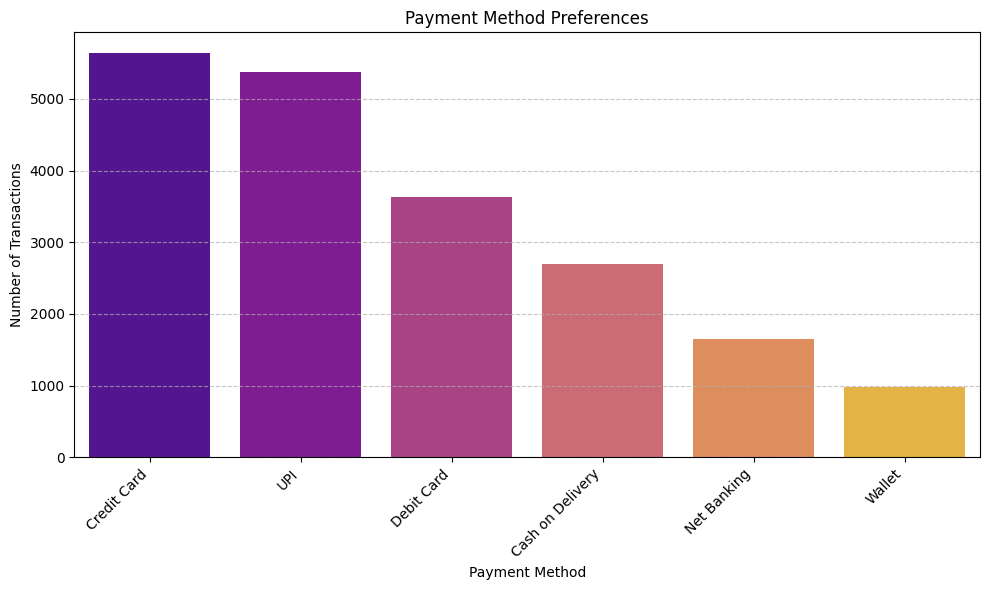

In [ ]:
# Visualize payment method preferences
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='PaymentMethod', y='Count', data=payment_method_counts, palette='plasma')
plt.title('Payment Method Preferences')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## High-Value Customers by Total Spending

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total spending per customer
customer_spending = df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).reset_index()

# Display the top 10 high-value customers
display(customer_spending.head(10))

,CustomerID,TotalAmount
0,CUST10158,44790.30
1,CUST10142,44101.10
2,CUST12728,43793.70
3,CUST11668,37637.87
4,CUST14400,37183.45
5,CUST11351,36948.61
6,CUST13019,36080.14
7,CUST12481,35477.63
8,CUST13605,35292.80
9,CUST13390,35127.54


/tmp/ipykernel_955/2265349406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalAmount', y='CustomerID', data=customer_spending.head(10), palette='magma')


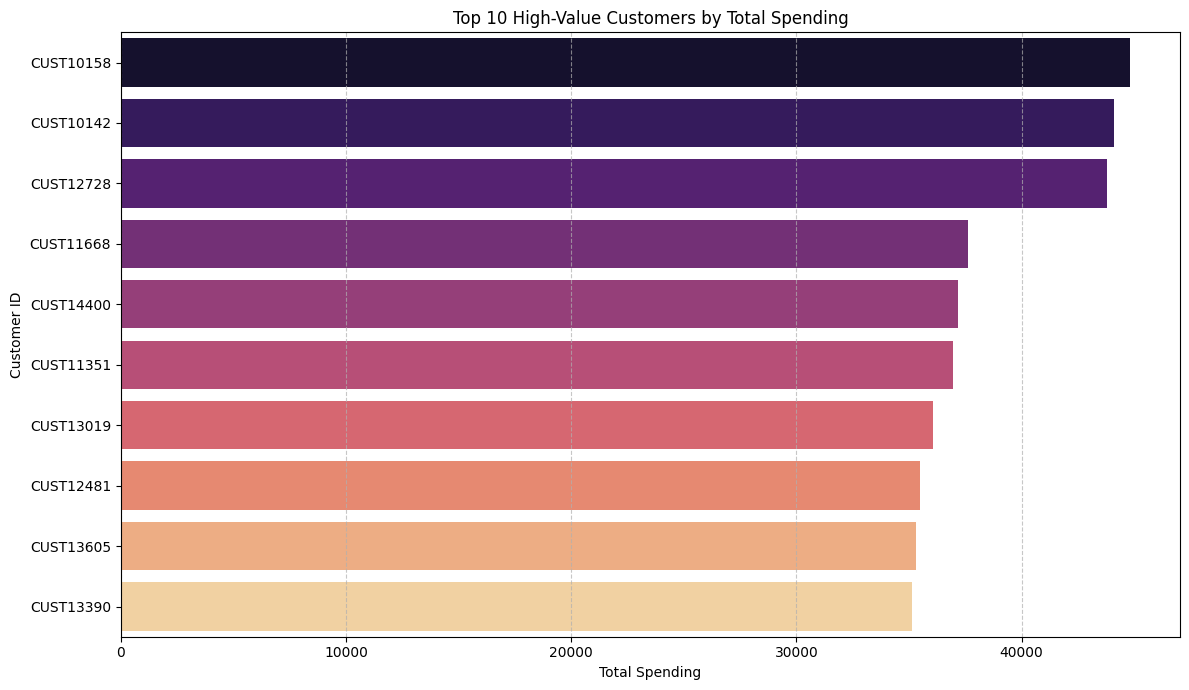

In [ ]:
# Visualize the top 10 high-value customers
fig = plt.figure(figsize=(12, 7))
sns.barplot(x='TotalAmount', y='CustomerID', data=customer_spending.head(10), palette='magma')
plt.title('Top 10 High-Value Customers by Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Customer ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Identifying High-Value Orders

To identify high-value orders, we'll define a threshold based on the `TotalAmount`. We can use statistical measures like the 75th percentile or a custom value to determine this threshold. For this analysis, I'll use the 75th percentile as a starting point to identify orders that are significantly larger than most others.

In [ ]:
import numpy as np

# Calculate descriptive statistics for 'TotalAmount'
display(df['TotalAmount'].describe())

# Define the threshold for high-value orders (e.g., 75th percentile)
high_value_threshold = df['TotalAmount'].quantile(0.75)
print(f"\nHigh-value order threshold (75th percentile): ${high_value_threshold:.2f}")

# Filter for high-value orders
high_value_orders = df[df['TotalAmount'] >= high_value_threshold]

# Display the count and first few rows of high-value orders
print(f"\nNumber of high-value orders: {len(high_value_orders)}")
display(high_value_orders.head())

,TotalAmount
count,19975.000000
mean,2276.359551
std,2407.242796
min,39.190000
25%,723.465000
50%,1565.780000
75%,2939.340000
max,24484.750000



High-value order threshold (75th percentile): $2939.34

Number of high-value orders: 4994


,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod,OrderMonth,price_band
2,ORD100002,2024-02-05,CUST13927,North,Fashion,Winter Jacket,1,3431.87,3431.87,UPI,2024-02,Very High
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery,2023-01,Very High
10,ORD100010,2023-10-02,CUST13158,North,Fashion,Sneakers,1,3197.55,3197.55,Credit Card,2023-10,Very High
11,ORD100011,2024-12-18,CUST15853,West,Home & Kitchen,Cutlery Set,2,2197.52,4395.04,Credit Card,2024-12,Very High
13,ORD100013,2024-09-24,CUST14566,West,Electronics,Power Bank,2,3402.96,6805.92,Credit Card,2024-09,Very High


## Creating a 'Price Band' Column

To further categorize orders, we can create a 'price-band' column based on the `TotalAmount`. This will help in understanding the distribution of orders across different value segments. I'll use the quartiles of `TotalAmount` to define these bands.

In [ ]:
# Define bins for price bands using quartiles
bins = [
    df['TotalAmount'].min() - 1,
    df['TotalAmount'].quantile(0.25),
    df['TotalAmount'].quantile(0.50),
    df['TotalAmount'].quantile(0.75),
    df['TotalAmount'].max() + 1
]

labels = ['Low', 'Medium', 'High', 'Very High']

# Create the 'price_band' column
df['price_band'] = pd.cut(df['TotalAmount'], bins=bins, labels=labels, right=False)

# Display the value counts for the new 'price_band' column
print("Value counts for 'price_band':")
display(df['price_band'].value_counts())

# Display the head of the DataFrame with the new 'price_band' column
print("\nDataFrame head with 'price_band' column:")
display(df.head())

Value counts for 'price_band':


,count
price_band,
Low,4994
High,4994
Very High,4994
Medium,4993



DataFrame head with 'price_band' column:


,OrderID,OrderDate,CustomerID,Region,Category,Product,Quantity,UnitPrice,TotalAmount,PaymentMethod,OrderMonth,price_band
0,ORD100000,2023-12-25,CUST10535,West,Fashion,Formal Shirt,1,1375.76,1375.76,Debit Card,2023-12,Medium
1,ORD100001,2023-06-06,CUST14643,West,Fashion,Denim Jeans,1,1811.95,1630.76,Credit Card,2023-06,High
2,ORD100002,2024-02-05,CUST13927,North,Fashion,Winter Jacket,1,3431.87,3431.87,UPI,2024-02,Very High
3,ORD100003,2024-02-09,CUST12633,South,Electronics,Bluetooth Speaker,3,783.88,2234.06,Credit Card,2024-02,High
4,ORD100004,2023-01-01,CUST12598,East,Electronics,Laptop Stand,1,4982.24,4982.24,Cash on Delivery,2023-01,Very High


## Payment Method Distribution (Pie Chart)

This pie chart illustrates the proportion of each payment method used by customers, offering a quick view of the most popular payment options.

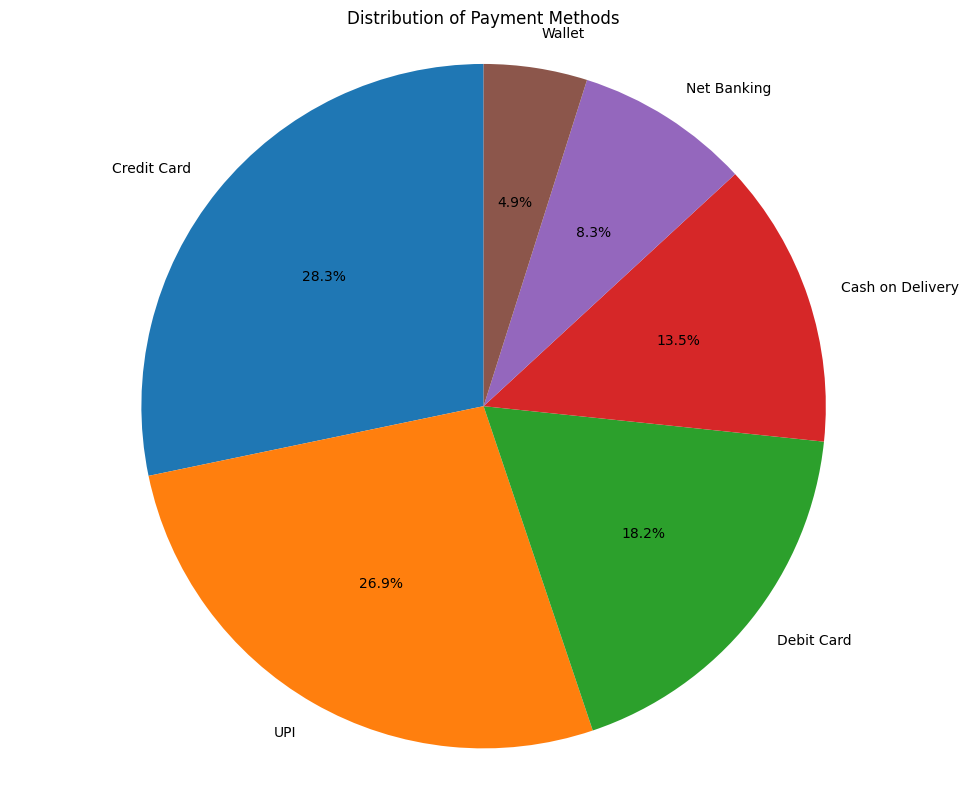

In [ ]:
import matplotlib.pyplot as plt

# Create a pie chart for payment method distribution
fig = plt.figure(figsize=(10, 8))
plt.pie(payment_method_counts['Count'], labels=payment_method_counts['PaymentMethod'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Payment Methods')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## Distribution of Order Values (Histogram)

This histogram displays the frequency distribution of `TotalAmount` for all orders, helping to understand the common ranges of order values and identify any outliers.

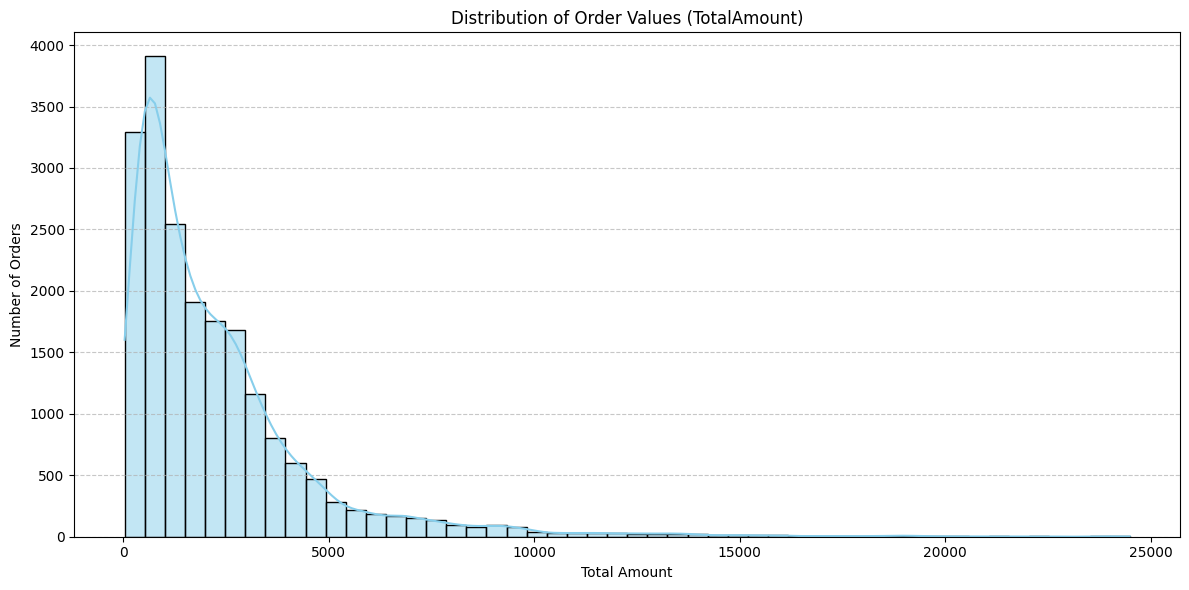

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a histogram for the distribution of order values
fig = plt.figure(figsize=(12, 6))
sns.histplot(df['TotalAmount'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Order Values (TotalAmount)')
plt.xlabel('Total Amount')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Order Frequency Trends by Month (Current Year)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the latest year (assuming 2024 based on previous monthly_sales output)
current_year = df['OrderDate'].dt.year.max()
df_current_year = df[df['OrderDate'].dt.year == current_year]

# Calculate order count by month for the current year
monthly_order_frequency = df_current_year.groupby(df_current_year['OrderDate'].dt.to_period('M')).size().reset_index(name='OrderCount')
monthly_order_frequency['OrderDate'] = monthly_order_frequency['OrderDate'].dt.to_timestamp()

# Display the monthly order frequency
display(monthly_order_frequency)

,OrderDate,OrderCount
0,2024-01-01,822
1,2024-02-01,794
2,2024-03-01,828
3,2024-04-01,874
4,2024-05-01,847
5,2024-06-01,819
6,2024-07-01,870
7,2024-08-01,847
8,2024-09-01,822
9,2024-10-01,862


/tmp/ipykernel_955/1577635868.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='OrderDate', y='OrderCount', data=monthly_order_frequency, marker='o', palette='viridis')


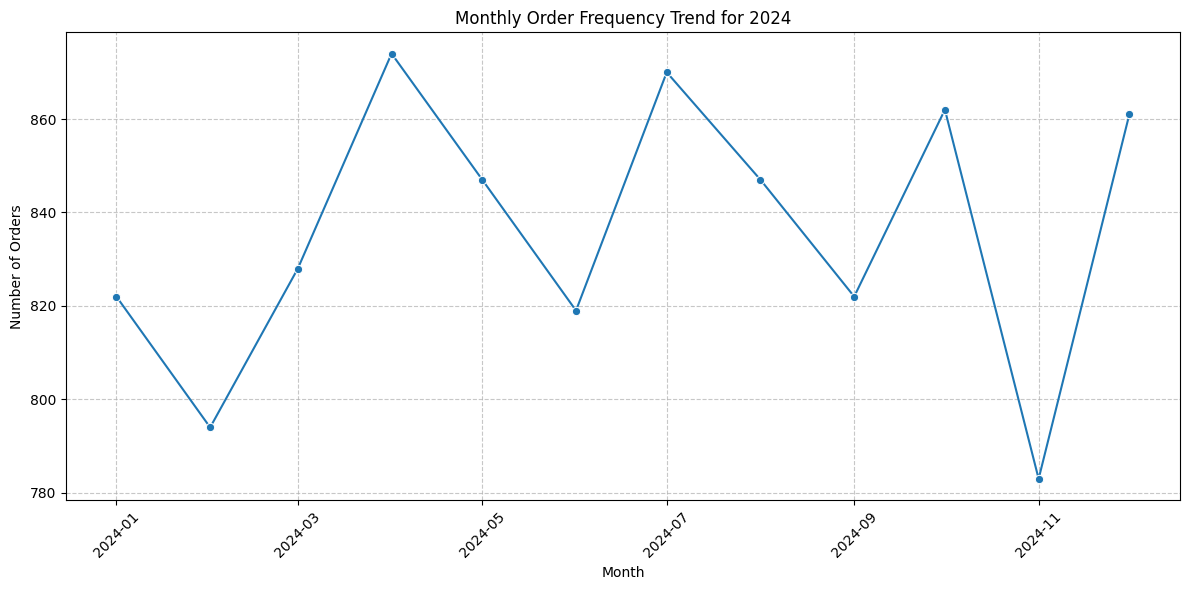

In [ ]:
# Visualize monthly order frequency
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x='OrderDate', y='OrderCount', data=monthly_order_frequency, marker='o', palette='viridis')
plt.title(f'Monthly Order Frequency Trend for {current_year}')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Insights and Summary

Based on the analysis, here are some key business insights:

*   **Revenue by Category**: Fashion and Electronics are the leading categories in terms of total revenue, indicating strong demand in these areas. Groceries and Sports also contribute significantly.
*   **Regional Performance**: The West and North regions show the highest revenue generation, suggesting these are key markets. The East and South regions also contribute, but to a lesser extent.
*   **Most Popular Products**: The top products by revenue include `Formal Shirt`, `Gaming Laptop`, and `Smartwatch`, reinforcing the importance of these items to overall sales.
*   **Monthly Sales Trend**: The monthly sales trend shows fluctuations, with peaks possibly aligning with holiday seasons or promotional periods. A deeper dive into seasonality would be beneficial.
*   **Payment Method Preferences**: Credit Card and UPI are the most preferred payment methods, followed by Debit Card and Cash on Delivery. This indicates a strong preference for digital payment options.
*   **High-Value Customers**: Identifying and focusing on high-value customers (those in the top quartile of spending) can be crucial for targeted marketing and loyalty programs.
*   **Order Value Distribution**: The distribution of order values is right-skewed, with a majority of orders falling into the 'Low' and 'Medium' price bands. This suggests a broad customer base with varying spending habits.
*   **Order Frequency Trends**: The monthly order frequency trend for the current year can help in forecasting demand and planning inventory.

**Overall Recommendations:**

1.  **Optimize High-Performing Categories/Products**: Continue to invest in and promote Fashion and Electronics products, and ensure stock availability for top-selling items.
2.  **Regional Focus**: Leverage insights from high-performing regions (West and North) to understand success factors and potentially replicate strategies in other regions.
3.  **Targeted Marketing**: Develop specific marketing campaigns for high-value customers and consider loyalty programs to retain them.
4.  **Payment Method Strategy**: Continue to support and optimize digital payment methods, as they are highly preferred by customers.
5.  **Seasonal Planning**: Utilize monthly sales and order frequency trends for better inventory management and marketing during peak seasons.
6.  **Value-Based Segmentation**: Use the 'price_band' column to tailor promotions and product offerings to different customer segments (Low, Medium, High, Very High spenders).